In [166]:
"""
Non-linear Classifier

In this code, we implement a model to classify points in vs. outside a circle
We limit -2 <= x <= 2 and -2 <= y <= 2
The radius of the circle is 1 so points within the circle are 

"""
import torch
import numpy as np
import torch.nn as nn
from sklearn.svm import SVC
from torch.utils.data import random_split
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [167]:
N = 1000
rad = 1
bx, by = 2, 2 # bounds for x and y

In [168]:
points_x, points_y = [], []
while len(points_x) < 2 * N: # for points inside the circle
    px, py = np.random.uniform(-bx, bx), np.random.uniform(-by, by)
    points_x.append((px, py))
    if np.sqrt(px**2 + py**2) <= rad:
        points_y.append(1)
    else:
        points_y.append(0)

points_x = np.array(points_x)
points_y = np.array(points_y)

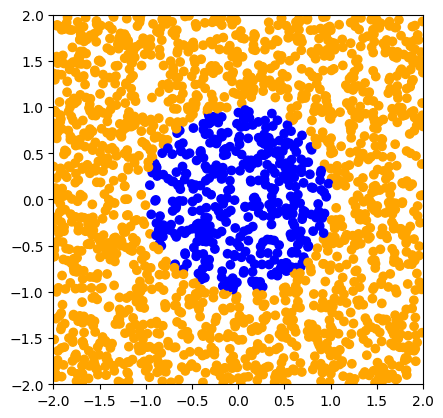

In [169]:
colors = np.where(points_y[:] == 1, 'blue', 'orange')

plt.scatter(points_x[:, 0], points_x[:, 1], c=colors)
plt.xlim(-bx, bx)
plt.ylim(-by, by)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [170]:
X_train, X_test, y_train, y_test = train_test_split(points_x, points_y, test_size=0.3)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
percentage = model.score(X_test, y_test)


In [171]:
from sklearn.metrics import confusion_matrix
res = confusion_matrix(y_test, predictions)
print("Confusion Matrix")
print(res)
print(f"Test Set: {len(X_test)}")
print(f"Accuracy = {percentage*100} %")

Confusion Matrix
[[492   0]
 [  3 105]]
Test Set: 600
Accuracy = 99.5 %


In [172]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU()
        )

    def forward(self, x):
        logits = self.linear(x)
        return logits

model = NeuralNetwork().to(device="cpu")
print(model)

NeuralNetwork(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
  )
)
